## Education by 2010 Census Tracts

In [137]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [174]:
# Load 2010 Census tracts for Philadelphia 
tracts_2010 = gpd.read_file("C:\\UC San Diego\\GPEC447\\FinalProject\\tl_2010_42101_tract10\\tl_2010_42101_tract10.shp")

In [175]:
tracts_2010.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,42,101,036301,42101036301,363.01,Census Tract 363.01,G5020,S,2322732,66075,+40.0895349,-074.9667387,"POLYGON ((-74.96188 40.09781, -74.96163 40.097..."
1,42,101,036400,42101036400,364,Census Tract 364,G5020,S,4501110,8014,+40.1127747,-074.9789137,"POLYGON ((-74.9778 40.1071, -74.97896 40.10617..."
2,42,101,036600,42101036600,366,Census Tract 366,G5020,S,1004313,1426278,+39.9470272,-075.1404472,"POLYGON ((-75.14147 39.9517, -75.14146 39.9521..."
3,42,101,034803,42101034803,348.03,Census Tract 348.03,G5020,S,1271533,8021,+40.0619427,-075.0023705,"POLYGON ((-75.00887 40.05865, -75.00915 40.059..."
4,42,101,034702,42101034702,347.02,Census Tract 347.02,G5020,S,1016206,0,+40.0570427,-075.0283288,"POLYGON ((-75.02543 40.06565, -75.02533 40.065..."


In [176]:
tracts_2010.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [177]:
tracts_2010.to_crs(2272, inplace=True)

### Join Education with Tracts

In [142]:
#Load 2010 education data by tract
educ_2010 = pd.read_csv("C:\\UC San Diego\\GPEC447\\FinalProject\\ACS2010Education\\ACSST5Y2010.S1501-Data.csv")

In [143]:
educ_2010.head()

,GEO_ID,NAME,S1501_C01_001E,S1501_C01_001M,S1501_C02_001E,S1501_C02_001M,S1501_C03_001E,S1501_C03_001M,S1501_C01_002E,S1501_C01_002M,...,S1501_C02_037M,S1501_C03_037E,S1501_C03_037M,S1501_C01_038E,S1501_C01_038M,S1501_C02_038E,S1501_C02_038M,S1501_C03_038E,S1501_C03_038M,Unnamed: 230
0,Geography,Geographic Area Name,Total!!Estimate!!Population 18 to 24 years,Total!!Margin of Error!!Population 18 to 24 years,Male!!Estimate!!Population 18 to 24 years,Male!!Margin of Error!!Population 18 to 24 years,Female!!Estimate!!Population 18 to 24 years,Female!!Margin of Error!!Population 18 to 24 y...,Total!!Estimate!!Less than high school graduate,Total!!Margin of Error!!Less than high school ...,...,Male!!Margin of Error!!MEDIAN EARNINGS IN THE ...,Female!!Estimate!!MEDIAN EARNINGS IN THE PAST ...,Female!!Margin of Error!!MEDIAN EARNINGS IN TH...,Total!!Estimate!!PERCENT IMPUTED!!Educational ...,Total!!Margin of Error!!PERCENT IMPUTED!!Educa...,Male!!Estimate!!PERCENT IMPUTED!!Educational a...,Male!!Margin of Error!!PERCENT IMPUTED!!Educat...,Female!!Estimate!!PERCENT IMPUTED!!Educational...,Female!!Margin of Error!!PERCENT IMPUTED!!Educ...,NaN
1,1400000US42101000100,"Census Tract 1, Philadelphia County, Pennsylvania",234,168,80,67,154,112,6.8,12.1,...,19370,65446,6991,3.0,(X),(X),(X),(X),-888888888,NaN
2,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",101,66,61,52,40,44,24.8,34.8,...,13879,89922,45036,0.6,(X),(X),(X),(X),-888888888,NaN
3,1400000US42101000300,"Census Tract 3, Philadelphia County, Pennsylvania",1476,2071,61,44,1415,2071,0.0,1.8,...,30619,81300,13814,2.5,(X),(X),(X),(X),-888888888,NaN
4,1400000US42101000401,"Census Tract 4.01, Philadelphia County, Pennsy...",205,133,106,119,99,71,0.0,12.5,...,108623,33558,23310,4.7,(X),(X),(X),(X),-888888888,NaN


In [144]:
# Drop first row (metadata)
educ_2010 = educ_2010.drop(0)

In [145]:
# Fix GEO_ID to match tracts
educ_2010["GEO_ID"] = educ_2010["GEO_ID"].str[9:]

In [146]:
print(educ_2010.dtypes)

GEO_ID             object
NAME               object
S1501_C01_001E     object
S1501_C01_001M     object
S1501_C02_001E     object
                   ...   
S1501_C02_038E     object
S1501_C02_038M     object
S1501_C03_038E     object
S1501_C03_038M     object
Unnamed: 230      float64
Length: 231, dtype: object


In [147]:
# Select columns
# S1501_C01_006E = Total!!Estimate!!Population 25 years and over
# S1501_C01_015E = Total!!Estimate!!Percent bachelor's degree or higher
educ_2010 = educ_2010[["GEO_ID", "NAME", "S1501_C01_006E", "S1501_C01_015E"]]

# Convert to numeric
educ_2010["S1501_C01_006E"] = pd.to_numeric(educ_2010["S1501_C01_006E"], errors='coerce')
educ_2010["S1501_C01_015E"] = pd.to_numeric(educ_2010["S1501_C01_015E"], errors='coerce')

# Rename columns
educ_2010 = educ_2010.rename(columns={"S1501_C01_006E": "total_25_plus", "S1501_C01_015E": "pct_bachelor_or_higher"})

In [148]:
educ_2010.head()

,GEO_ID,NAME,total_25_plus,pct_bachelor_or_higher
1,42101000100,"Census Tract 1, Philadelphia County, Pennsylvania",2752,72.3
2,42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",1602,33.3
3,42101000300,"Census Tract 3, Philadelphia County, Pennsylvania",2551,68.8
4,42101000401,"Census Tract 4.01, Philadelphia County, Pennsy...",1247,71.5
5,42101000402,"Census Tract 4.02, Philadelphia County, Pennsy...",2942,58.9


In [149]:
# Add column for lower than bachelor's degree
educ_2010["pct_bachelor_lower"] = 100 - educ_2010["pct_bachelor_or_higher"]

In [178]:
# Join education data to tracts
tracts_2010 = tracts_2010.merge(educ_2010, left_on="GEOID10", right_on="GEO_ID")

In [179]:
tracts_2010.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry,GEO_ID,NAME,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower
0,42,101,036301,42101036301,363.01,Census Tract 363.01,G5020,S,2322732,66075,+40.0895349,-074.9667387,"POLYGON ((2748366.299 290799.127, 2748435.97 2...",42101036301,"Census Tract 363.01, Philadelphia County, Penn...",2604,15.6,84.4
1,42,101,036400,42101036400,364,Census Tract 364,G5020,S,4501110,8014,+40.1127747,-074.9789137,"POLYGON ((2743809.154 294040.402, 2743494.584 ...",42101036400,"Census Tract 364, Philadelphia County, Pennsyl...",393,1.8,98.2
2,42,101,036600,42101036600,366,Census Tract 366,G5020,S,1004313,1426278,+39.9470272,-075.1404472,"POLYGON ((2699720.168 236062.074, 2699719.035 ...",42101036600,"Census Tract 366, Philadelphia County, Pennsyl...",1139,75.4,24.6
3,42,101,034803,42101034803,348.03,Census Tract 348.03,G5020,S,1271533,8021,+40.0619427,-075.0023705,"POLYGON ((2735668.565 276129.136, 2735577.548 ...",42101034803,"Census Tract 348.03, Philadelphia County, Penn...",3305,19.9,80.1
4,42,101,034702,42101034702,347.02,Census Tract 347.02,G5020,S,1016206,0,+40.0570427,-075.0283288,"POLYGON ((2730958.367 278534.172, 2730985.876 ...",42101034702,"Census Tract 347.02, Philadelphia County, Penn...",3300,28.3,71.7


## Education by 2020 Census Tracts

In [ ]:
# Load 2020 Census tracts for Philadelphia 
tracts_2020 = gpd.read_file("C:\\UC San Diego\\GPEC447\\FinalProject\\tl_2020_42_tract\\tl_2020_42_tract.shp")

In [153]:
tracts_2020.to_crs(2272, inplace=True)

In [154]:
tracts_2020.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,42,095,017703,42095017703,177.03,Census Tract 177.03,G5020,S,3708021,9639,+40.6498956,-075.3948647,"POLYGON ((2617473.825 488293.417, 2618424.632 ..."
1,42,101,012204,42101012204,122.04,Census Tract 122.04,G5020,S,879459,56473,+40.0009407,-075.2120769,"POLYGON ((2676981.178 254440.769, 2677375.454 ..."
2,42,129,804300,42129804300,8043,Census Tract 8043,G5020,S,1014739,0,+40.2918690,-079.5478131,"POLYGON ((1464935.135 354814.612, 1464947.835 ..."
3,42,129,804801,42129804801,8048.01,Census Tract 8048.01,G5020,S,6852606,0,+40.3011416,-079.6013733,"POLYGON ((1444658.273 360201.039, 1444672.735 ..."
4,42,129,805200,42129805200,8052,Census Tract 8052,G5020,S,1873022,0,+40.1523157,-079.8745928,"POLYGON ((1372168.652 306146.629, 1372182.815 ..."


### Join Education with Tracts

In [155]:
#Load 2020 education data by tract
educ_2020 = pd.read_csv("C:\\UC San Diego\\GPEC447\\FinalProject\\ACS2020Education\\ACSST5Y2020.S1501-Data.csv")

In [156]:
educ_2020.head()

,GEO_ID,NAME,S1501_C01_001E,S1501_C01_001M,S1501_C01_002E,S1501_C01_002M,S1501_C01_003E,S1501_C01_003M,S1501_C01_004E,S1501_C01_004M,...,S1501_C06_060M,S1501_C06_061E,S1501_C06_061M,S1501_C06_062E,S1501_C06_062M,S1501_C06_063E,S1501_C06_063M,S1501_C06_064E,S1501_C06_064M,Unnamed: 770
0,Geography,Geographic Area Name,Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT...,Margin of Error!!Total!!AGE BY EDUCATIONAL ATT...,Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT...,Margin of Error!!Total!!AGE BY EDUCATIONAL ATT...,Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT...,Margin of Error!!Total!!AGE BY EDUCATIONAL ATT...,Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT...,Margin of Error!!Total!!AGE BY EDUCATIONAL ATT...,...,Margin of Error!!Percent Female!!MEDIAN EARNIN...,Estimate!!Percent Female!!MEDIAN EARNINGS IN T...,Margin of Error!!Percent Female!!MEDIAN EARNIN...,Estimate!!Percent Female!!MEDIAN EARNINGS IN T...,Margin of Error!!Percent Female!!MEDIAN EARNIN...,Estimate!!Percent Female!!MEDIAN EARNINGS IN T...,Margin of Error!!Percent Female!!MEDIAN EARNIN...,Estimate!!Percent Female!!MEDIAN EARNINGS IN T...,Margin of Error!!Percent Female!!MEDIAN EARNIN...,NaN
1,1400000US42101000101,"Census Tract 1.01, Philadelphia County, Pennsy...",57,49,0,11,6,9,23,36,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
2,1400000US42101000102,"Census Tract 1.02, Philadelphia County, Pennsy...",299,257,41,47,29,45,26,35,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
3,1400000US42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",354,154,0,11,85,61,39,37,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN
4,1400000US42101000300,"Census Tract 3, Philadelphia County, Pennsylvania",391,143,0,11,47,35,209,124,...,(X),(X),(X),(X),(X),(X),(X),(X),(X),NaN


In [157]:
# Drop first row (metadata)
educ_2020 = educ_2020.drop(0)

In [158]:
# Fix GEO_ID to match tracts
educ_2020["GEO_ID"] = educ_2020["GEO_ID"].str[9:]

In [159]:
# Select columns
# S1501_C01_006E = Total!!Estimate!!Population 25 years and over
# S1501_C01_015E = Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Bachelor's degree or higher
educ_2020 = educ_2020[["GEO_ID", "NAME", "S1501_C01_006E", "S1501_C01_015E"]]

# Convert to numeric
educ_2020["S1501_C01_006E"] = pd.to_numeric(educ_2020["S1501_C01_006E"], errors='coerce')
educ_2020["S1501_C01_015E"] = pd.to_numeric(educ_2020["S1501_C01_015E"], errors='coerce')

In [160]:
# Calculate percent of bachelors or higher in 2020
educ_2020["S1501_C01_015E"] = (educ_2020["S1501_C01_015E"] / educ_2020["S1501_C01_006E"]) * 100

In [164]:
# Rename columns
educ_2020 = educ_2020.rename(columns={"S1501_C01_006E": "total_25_plus", "S1501_C01_015E": "pct_bachelor_or_higher"})

In [165]:
# Add column for lower than bachelor's degree
educ_2020["pct_bachelor_lower"] = 100 - educ_2020["pct_bachelor_or_higher"]

In [166]:
educ_2020.head()

,GEO_ID,NAME,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower
1,42101000101,"Census Tract 1.01, Philadelphia County, Pennsy...",1708,91.627635,8.372365
2,42101000102,"Census Tract 1.02, Philadelphia County, Pennsy...",2549,81.796783,18.203217
3,42101000200,"Census Tract 2, Philadelphia County, Pennsylvania",2526,50.237530,49.762470
4,42101000300,"Census Tract 3, Philadelphia County, Pennsylvania",2924,82.147743,17.852257
5,42101000401,"Census Tract 4.01, Philadelphia County, Pennsy...",2297,81.802351,18.197649


In [167]:
# Join education data to tracts
tracts_2020 = tracts_2020.merge(educ_2020, left_on="GEOID", right_on="GEO_ID", how="inner")

In [169]:
tracts_2020.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,GEO_ID,NAME_y,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower
0,42,101,012204,42101012204,122.04,Census Tract 122.04,G5020,S,879459,56473,+40.0009407,-075.2120769,"POLYGON ((2676981.178 254440.769, 2677375.454 ...",42101012204,"Census Tract 122.04, Philadelphia County, Penn...",3219,44.920783,55.079217
1,42,101,012203,42101012203,122.03,Census Tract 122.03,G5020,S,227696,0,+40.0074872,-075.2093403,"POLYGON ((2678861.975 255056.314, 2678866.419 ...",42101012203,"Census Tract 122.03, Philadelphia County, Penn...",626,65.495208,34.504792
2,42,101,013602,42101013602,136.02,Census Tract 136.02,G5020,S,246812,0,+39.9716057,-075.1800748,"POLYGON ((2686906.79 243645.714, 2686997.702 2...",42101013602,"Census Tract 136.02, Philadelphia County, Penn...",3269,83.328235,16.671765
3,42,101,034502,42101034502,345.02,Census Tract 345.02,G5020,S,1021734,0,+40.0814101,-075.0384569,"POLYGON ((2724650.476 284639.902, 2724859.044 ...",42101034502,"Census Tract 345.02, Philadelphia County, Penn...",3940,41.573604,58.426396
4,42,101,000902,42101000902,9.02,Census Tract 9.02,G5020,S,155167,0,+39.9471596,-075.1566389,"POLYGON ((2694530.584 234145.037, 2694537.691 ...",42101000902,"Census Tract 9.02, Philadelphia County, Pennsy...",2251,69.258108,30.741892


In [168]:
tracts_2020.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   STATEFP                 408 non-null    object  
 1   COUNTYFP                408 non-null    object  
 2   TRACTCE                 408 non-null    object  
 3   GEOID                   408 non-null    object  
 4   NAME_x                  408 non-null    object  
 5   NAMELSAD                408 non-null    object  
 6   MTFCC                   408 non-null    object  
 7   FUNCSTAT                408 non-null    object  
 8   ALAND                   408 non-null    int64   
 9   AWATER                  408 non-null    int64   
 10  INTPTLAT                408 non-null    object  
 11  INTPTLON                408 non-null    object  
 12  geometry                408 non-null    geometry
 13  GEO_ID                  408 non-null    object  
 14  NAME_y            

<Axes: >

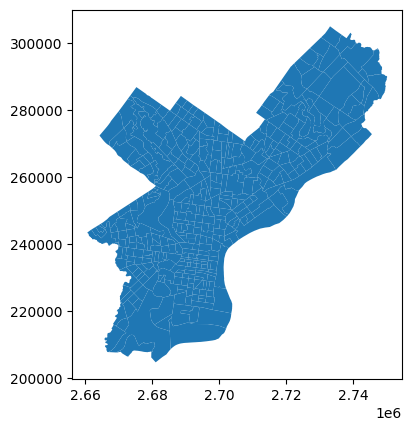

In [170]:
tracts_2020.plot()